## Arbre de régression

### Chargement des données

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# %matplotlib inline
# import matplotlib.pyplot as plt
# import matplotlib
# print("Backend:", matplotlib.get_backend())

Data = pd.read_csv('bebe.csv')
df = pd.DataFrame(data = Data)
print(df.describe())

Backend: inline
                 X          bwt    gestation       parity          age  \
count  1174.000000  1174.000000  1174.000000  1174.000000  1174.000000   
mean    587.500000  3386.702747   279.101363     0.262351    27.228279   
std     339.048915   519.608671    16.010305     0.440100     5.817839   
min       1.000000  1559.222500   148.000000     0.000000    15.000000   
25%     294.250000  3061.746000   272.000000     0.000000    23.000000   
50%     587.500000  3401.940000   280.000000     0.000000    26.000000   
75%     880.750000  3713.784500   288.000000     1.000000    31.000000   
max    1174.000000  4989.512000   353.000000     1.000000    45.000000   

            height       weight        smoke  
count  1174.000000  1174.000000  1174.000000  
mean    162.685486    58.276913     0.390971  
std       6.416298     9.404905     0.488176  
min     134.620000    39.462504     0.000000  
25%     157.480000    51.822886     0.000000  
50%     162.560000    56.699000    

In [2]:
mydf = df.drop('X', axis=1)
print(mydf.head())

         bwt  gestation  parity  age  height     weight  smoke
0  3401.9400        284       0   27  157.48  45.359200      0
1  3203.4935        282       0   33  162.56  61.234920      0
2  3628.7360        279       0   28  162.56  52.163080      1
3  3061.7460        282       0   23  170.18  56.699000      1
4  3855.5320        286       0   25  157.48  42.184056      0


**Question**: Commentez les valeurs médianes pour les variables quantitatives et les modalités les plus représentées pour les variables qualitatives.

**Réponse**: On ramarque que dans un premier temps pour les valeurs quantitatives, 39% des mères fument et que 26% des mère ont un unique enfant. Dans un second temps on remarque que les valeurs sont plutôt stable pour le poids du bébé, hauteur, poids de la mère etc.

**Question**:Y-a-t-il des valeurs manquantes ? Pourquoi cela peut-il être un problème pour l'entrainement du modèle ?

**Réponse**: Il aurait fallu surement les mêmes informations de la mère pour le bébé (dans la limite de la logique bien entendu) comme la taille. 

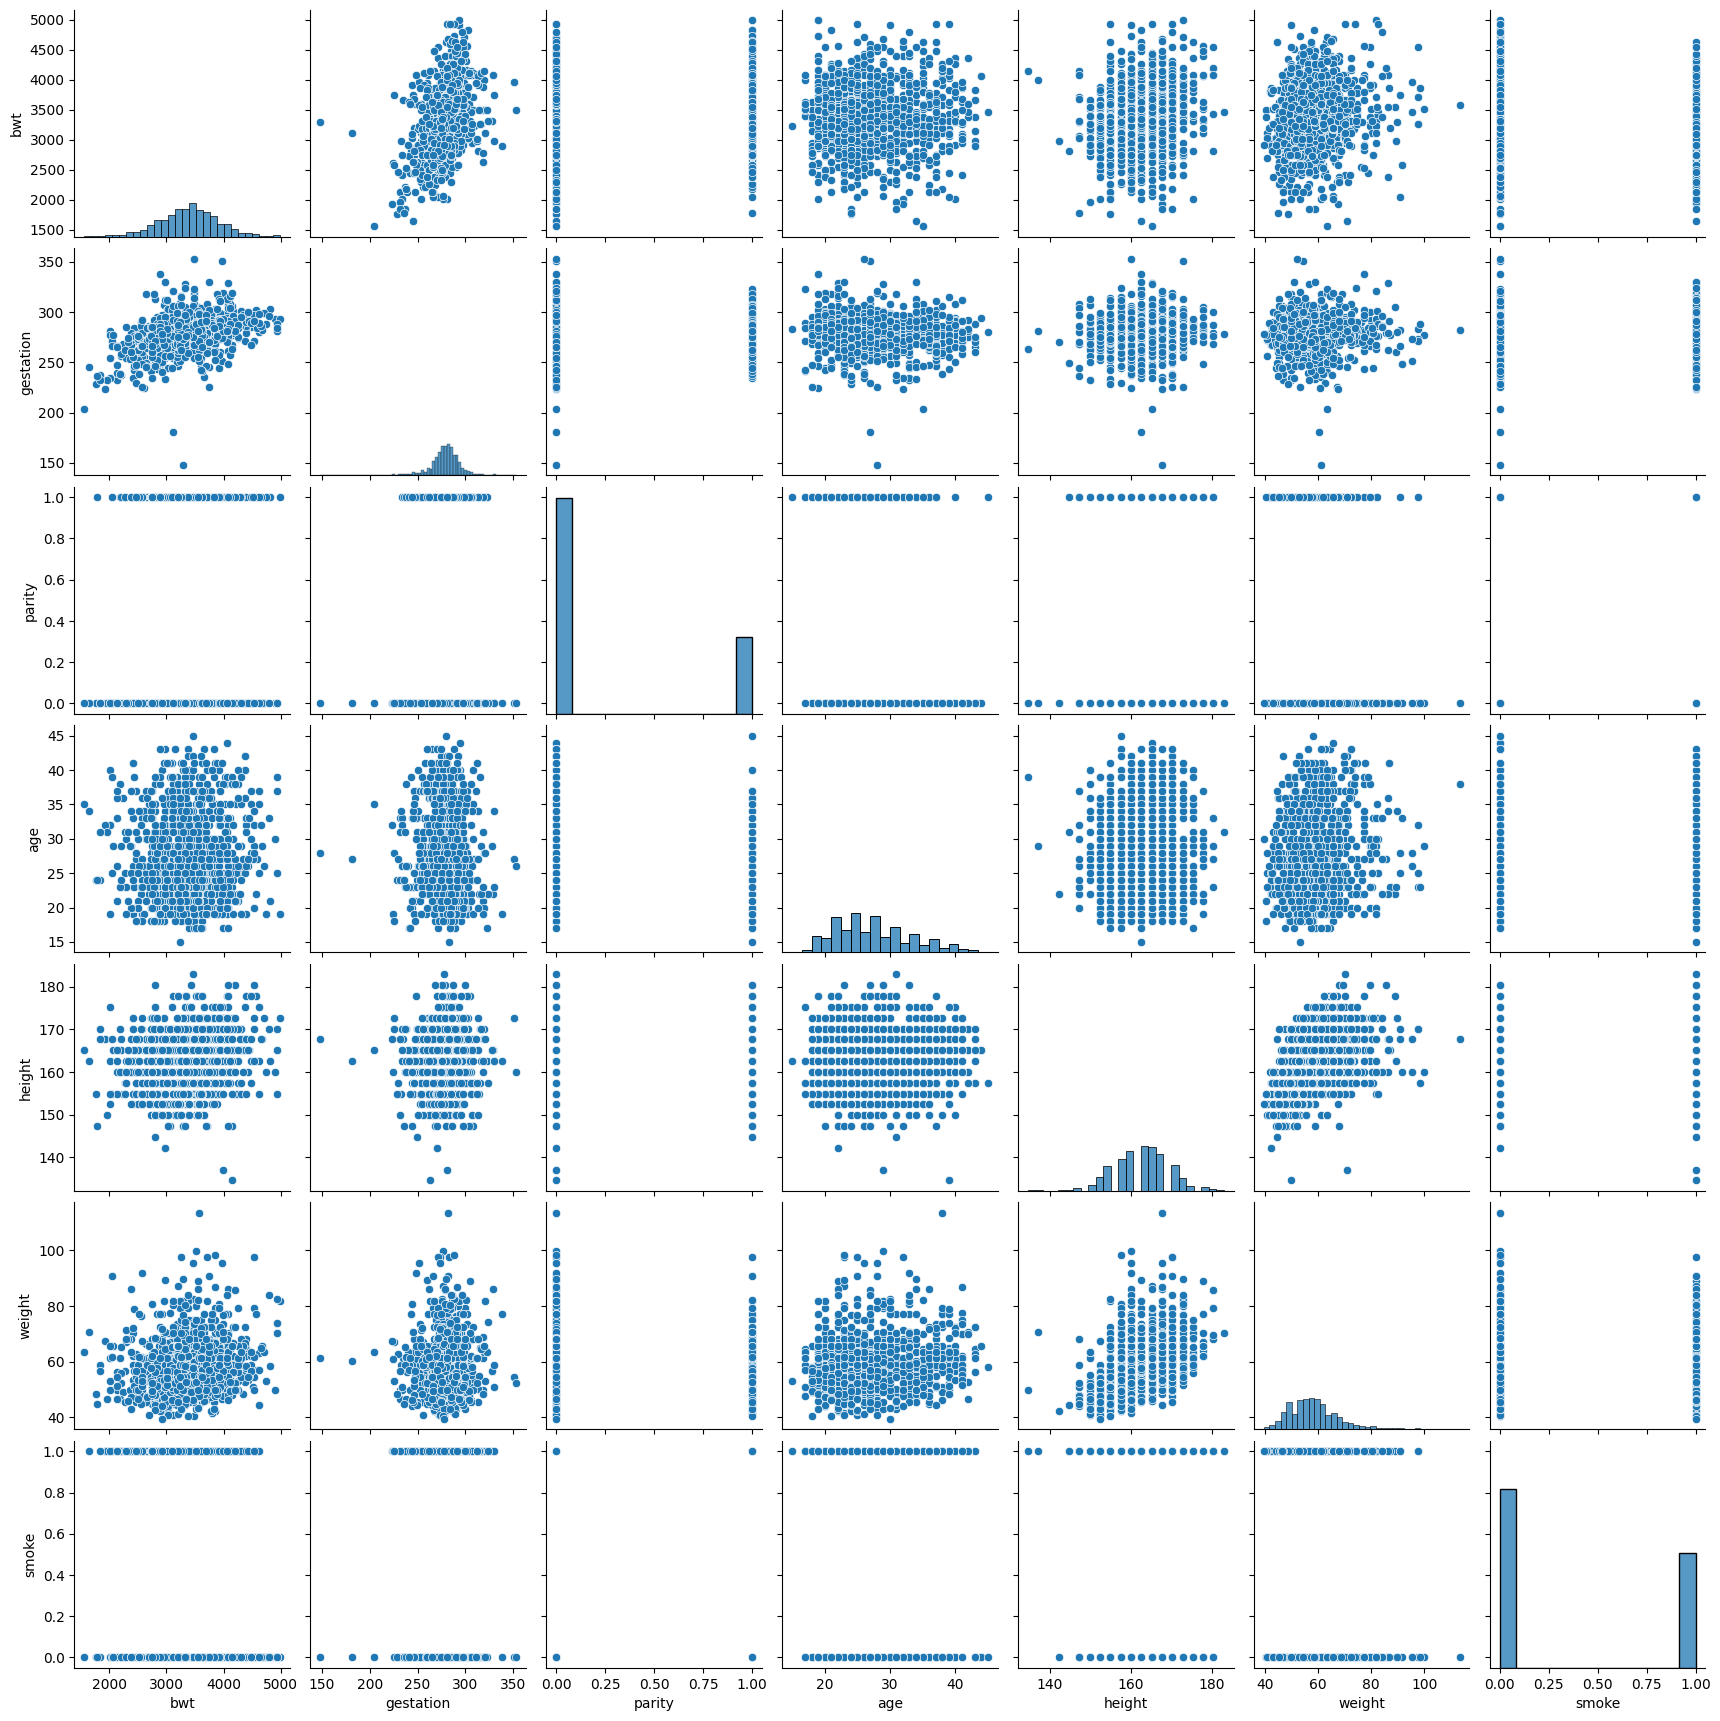

In [3]:
sns.pairplot(mydf)
plt.show()

**Question:** Identifiez les fortes corrélations entre les variables

**Réponse:** On remarque que plus le poids du bébé augmente (```bwt```) plus la durée de la grossesse augmente (```gestation```).  
De plus, on peut remarquer que plus une femme est grande (```height```) plus son poids est aussi grand (```weight```).

**Question:** Identifiez les faibles corrélations entre les variables. 

**Réponse:** Honnêtement puisqu'il n'existe pas beaucoup de variable qui sont en corrélation, on peut prendre un exemple telle que le poids de la mère (```weight```) et le poids du bébé (```bwt```) les deux sont plutot stables entre eux.

**Question**: Y-a-t-il plus de mère fumeuses ou non fumeuse ?

**Réponse**: On remarque si on regarde le graphe en bas à droite (qui représente ```smoke```) que la barre des personnes qui ne fument pas (smoke = 0) est plus élevé que celle de ceux qui fument (smoke = 1), donc il y a plus de mère non fumeuse que fumeuse.

In [4]:
# On contruit les dataframes X_train, X_test, Y_train, Y_test
from sklearn.model_selection import train_test_split

X = mydf.drop('bwt', axis=1) # X contient les variables explicatives
Y = mydf['bwt'] # Y contient la variable à prédire

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

### *DecisionTreeRegressor* du package *scikit-learn*

Nous utiliserons l’implémentation de sklearn d’un d’arbre de régression et, pour
apprendre à l’utiliser, voici les éléments suivants docs ou vous pouvez mettre un
point d’interrogation avant un appel l’objet.  
L’ajout d’un ? à une méthode, une variable ou une fonction affichera la doc définie de cette méthode.

Cette fonction DecisionTreeRegressor génère un arbre par partitionnement récursif
binaire en utilisant la variable qu’on souhaite prédire (mise dans une formule spéci-
fiée en entrée) et en fractionnement les variables explicatives.  
La variable à prédire doit être continue pour un arbre de régression et binaire pour un arbre de classi-
fication. La variable à prédire est divisée en $X < a$ et $X > a$, de façon itérative et
en faisant varier la valeur de a. La scission a est la valeur qui maximise la réduction
de la variance (pour un abre de régression et l’ "impureté" pour un arbre de classifi-
cation .  

Le fractionnement itératif est poursuivi jusqu’à ce que les nœuds terminaux
soient trop petits ou trop peu différentiables pour être divisés. Appliquez la fonction
DecisionTreeRegressor sur votre dataframe pour prédire la variable btw à partir
de toutes les variables.

In [5]:
from sklearn.tree import DecisionTreeRegressor
# ?DecisionTreeRegressor # Permet de voir les paramètres du modèle

Nous allons construire un arbre assez simple pour le début. Il faut dans un premier
temps créer l’objet avec ses paramètres et dans un second temps l’appliquer à un
dataframe.

In [6]:
# Fit regression model
regr_1 = DecisionTreeRegressor(max_depth=2)
regr_1.fit(X_train, Y_train) 

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


Nous allons utiliser la librairie *matplotlib* et tree de *sklearn* pour afficher l’arbre
obtenu. Il faut spécifier les informations/dimensions que l’on souhaite obtenir pour
faciliter la lecture.

In [ ]:
import matplotlib
matplotlib.use('nbagg')

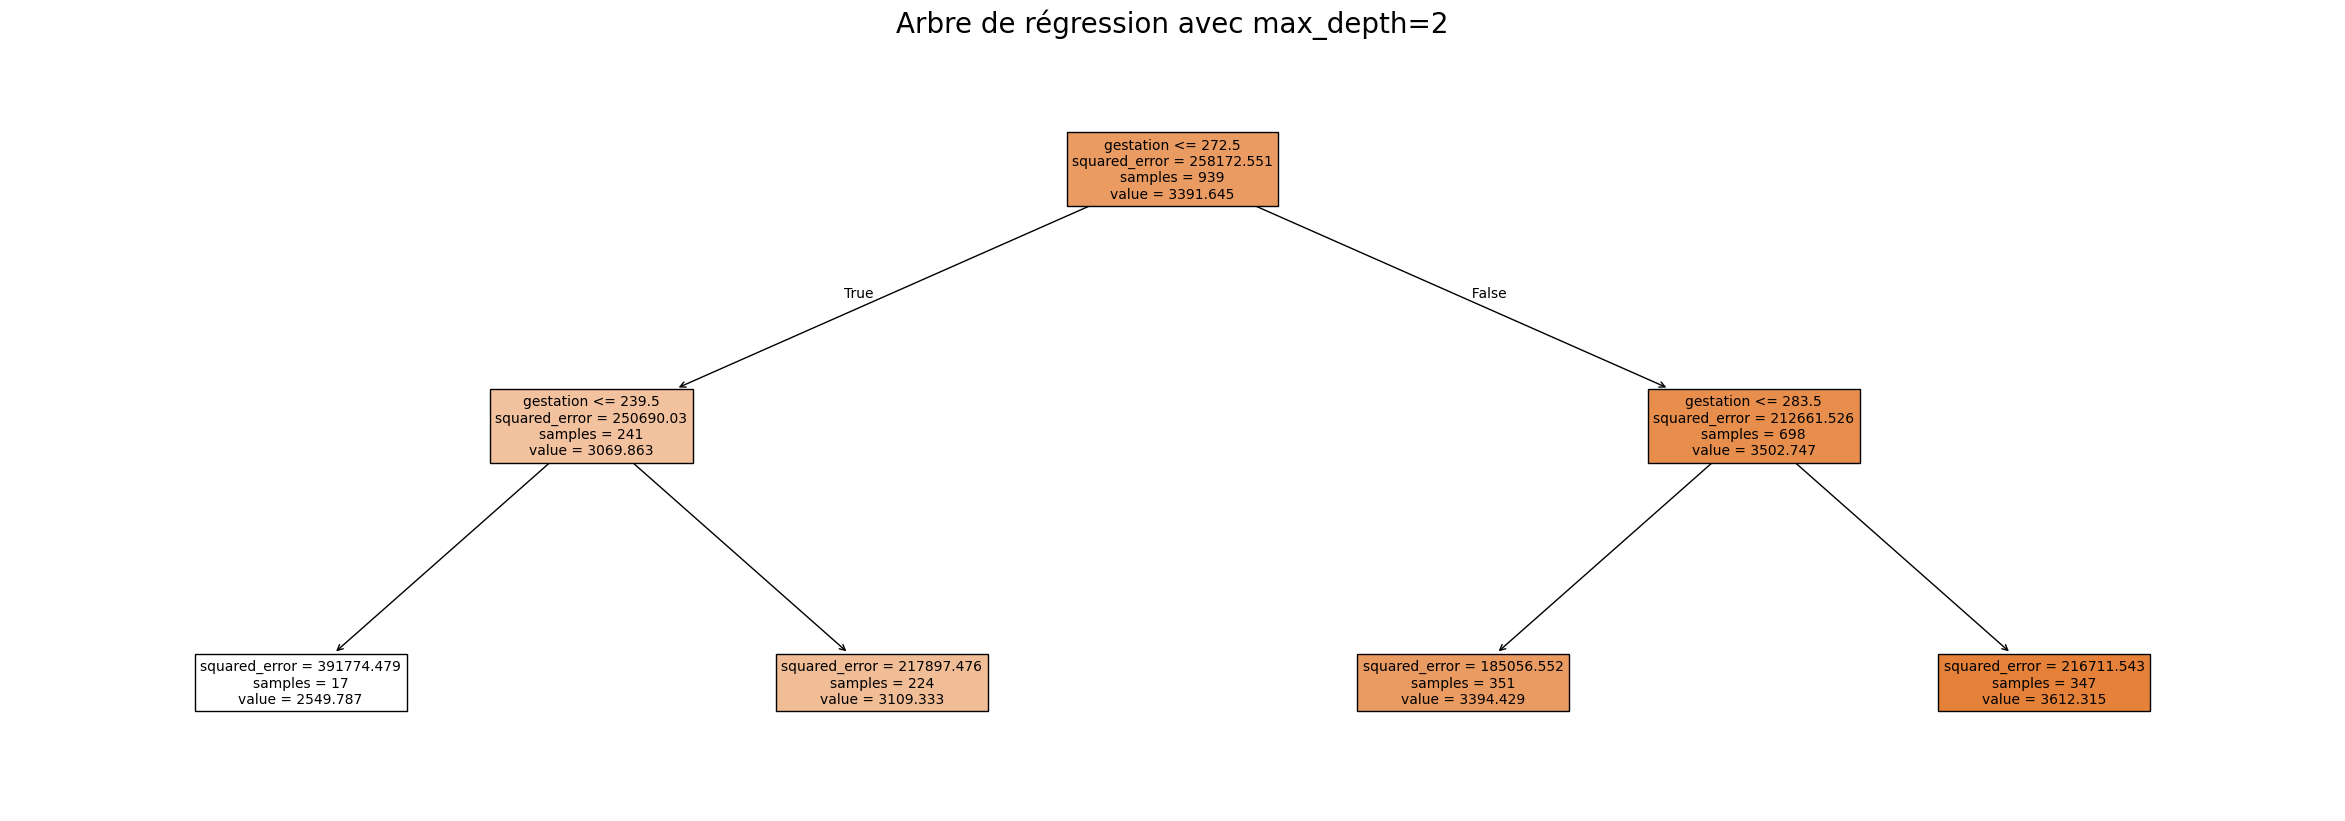

In [8]:
import matplotlib.pyplot as plt

from sklearn import tree
dt_feature_names = list(X_train.columns)

# plot tree
plt.figure(figsize=(30,10)) # set plot size (denoted in inches)
tree.plot_tree(regr_1, fontsize=10, filled=True, feature_names=dt_feature_names)
plt.title("Arbre de régression avec max_depth=2", fontsize=20)
plt.show()

Vous remarquerez dans l’arbre de la figure que vous avez exclusivement des
variables quantitative.  
Si vous souhaitez intégrer des variables binaires, il faudra faire une **transformation**, ce que nous verrons plus tard.
Nous allons maintenant tester notre modèle sur des données qu’il n’a pas vue. Pour cela, on lui demande de prédire pour le jeu de test le poids en ayant uniquement accès aux autres variables (explicatives), c’est à dire gestation, parity, age, height et smoke.  

Un premier moyen d’évaluation et d’observer le $R2$, la *mean square error*, et
la *root mean square error*.  
Une seconde évaluation, consiste à observer visuellement les données prédites par rapport aux données réelles.

In [9]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

y_1 = regr_1.predict ( X_test )
mse = mean_squared_error ( Y_test , y_1 )
score = r2_score ( Y_test , y_1 )

print (" R - squared :" , score )
print (" MSE : " , mse )
print (" RMSE : " , mse **(1/2.0) )

 R - squared : 0.26806721288147817
 MSE :  230989.86283682002
 RMSE :  480.6140476898486


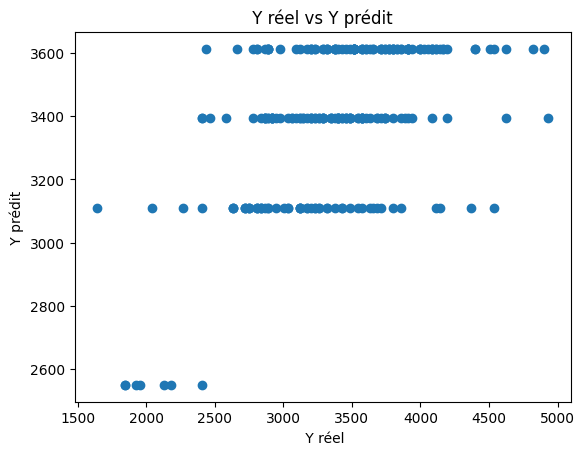

In [10]:
plt.scatter ( Y_test , y_1)
plt.title (" Y réel vs Y prédit ")
plt.xlabel (" Y réel")
plt.ylabel (" Y prédit ")
plt.show()

**Questions**:  
- a) Commentez l'arbre obtenu (description des groupes) . Quelle est/sont les variables de *split* les plus discriminantes ?  
- b) Donnez la formule pour calculer manuellement le $R^2$ et la $MSE$. Retrouvez les résultats obtenus avec sklearn.
- c) Commentez le $R2$ obtenu. Comparez le avec le $R2$ issue des données d'entraînements. Est-on en *underfit* ou *overfit* ?
- d) Commentez le graphe "*Y réel vs Y prédit*" . Comment se comporte le modèle ?

**Réponse:**
- a) On ramarque dans l'arbre obtenue que la variable la plus pertinante pour dans un premier temps (puisque ```max_depth = 2```) déterminer le ```bwt``` est ```gestation```. On a alors les groupes de bébés dont la mère a accouché avant dans les intervalles de jours suivants $[239.5, 272.5, 283.5]$.
On remarque que les variables de split les plus discriminante sont celles quand la mère a accouché avant 239.5 jours  (soit 16 mères) et entre 239.5 et 272.5 jours (soit 196 mères).

- b) La formule du score $R^2$ est la suivante: 
$$
R^2 = 1 - \frac{\sum^n_{i = 1}(y_i - \hat{y_i})^2}{\sum^n_{i = 1}(y_i - \bar{y})^2}
$$
Et celle du MSE:  
$$
MSE = \frac{1}{n}\sum_{i=1}^n{(y_i - \hat{y_i})^2}
$$

In [11]:
# On récupère les résultats R2 et MSE obtenus
results = pd.DataFrame({
    'Model': ['Decision Tree Regressor (max_depth=2)'],
    'R-squared': [score],
    'MSE': [mse],
    'RMSE': [mse **(1/2.0)]
})
print(results) 

                                   Model  R-squared            MSE        RMSE
0  Decision Tree Regressor (max_depth=2)   0.268067  230989.862837  480.614048


- Le résultat obtenue pour $R2$ est égale à $0.268$ ce qui n'est pas très performant...  
En comparant avec le $R2$ issue des données d'entrainement: 

In [12]:
# On affiche le R2 des donnée d'entrainement
y_train_pred = regr_1.predict(X_train)
train_score = r2_score(Y_train, y_train_pred)
print("R-squared (train):", train_score)

R-squared (train): 0.19305458316777657


on remarque que le $R2$ des donnée d'entrainements son aussi très faible, si nos deux score sont faible, cela signifie que notre modèle est en ***underfit***.

d) Si on regarde le résultat de *DecisionTreeRegressor* on ramarque que les prédictions peuvent êtres totallement fausses par rapport à la valeur prévue. Par exemple pour une valeur prédite à 3400 on a des valeurs réelles qui vont de 2500 à 4300~, une trop grosse marge qui rends se modèle peut efficace.

### Parameter tuning  

Pour réduire la variance, nous contraignons le modèle en utilisant certains des
paramètres fournis, par exemple : 
- ```criterion``` (Fonction de coût utilisée pour mesurer la pureté d’un fractionnement) 
- ```max_depth``` taille maximale de l’arbre 
- ```min_samples_split``` Echantillons minimums pour chaque nœud scindé 
- ```min_samples_leaf``` Echantillons minimums pour chaque noeud terminal 
- ```max_leaf_nodes``` Nombre maximal de nœuds terminaux.  

Vous pouvez également trouver plus d’informations sur <a href="https://www.analyticsvidhya.com/blog/2016/04/tree-based-algorithms-complete-tutorial-scratch-in-python/#four">ce blog</a> pour un rappel des paramètres de l’arbre de décision.  
Dans un premier temps, nous allons expérimenter avec le paramètre max_depth
uniquement. Par le code suivant vous permet par exemple de comparer y1 et y2
(prédictions issues sous deux paramétrages différents) selon la variable explicative
```gestation```.

**Question**: Construisez un arbre avec une profondeur maximale de 3.

In [13]:
# Construction d'un arbre avec une profondeur de max de 3
regr_2 = DecisionTreeRegressor(max_depth=3)
regr_2.fit(X_train, Y_train)
y_2 = regr_2.predict(X_test)

mse_2 = mean_squared_error(Y_test, y_2)
score_2 = r2_score(Y_test, y_2)
print("R-squared (test) avec une profondeur max de 3:", score_2)
print("MSE (test) avec une profondeur max de 3:", mse_2)

R-squared (test) avec une profondeur max de 3: 0.22228933073408574
MSE (test) avec une profondeur max de 3: 245436.85428779048


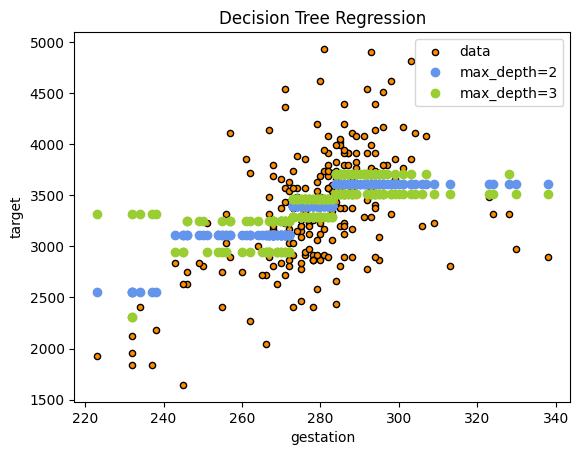

In [ ]:
X_test_temp = X_test.loc [:,X_test.columns == "gestation"]

# Plot the results
plt.figure()
plt.scatter(X_test_temp, Y_test, s=20, edgecolors="black", c="darkorange", label="data")
plt.plot(X_test_temp, y_1, 'o', color="cornflowerblue", label="max_depth=2")
plt.plot(X_test_temp, y_2, 'o', color="yellowgreen", label="max_depth=3")
plt.xlabel("gestation")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

**Questions**:
- b) Interprétez l'arbre obtenu. Queslle autre variable a fait son apparition ?
- c) Quelles sont les variables qui influencent le poids d'un nourrisson ?
- d) Comparez les résultats avec le premier modèle de sort d'obtenir le graphique d'au dessus
- e) Comparez le $R^2$
- f) Comparez le $MSE$ et la $RMSE$ pour les deux modèles
- g) Quel est le meilleur modèle ?
- h) Pensez-vous que l'arbre de décision est une méthode adapté pour ce jeu de données. Si ce n'est pas le cas, quel autre modèle pourrait être utiliser.